In [19]:
## Importing Dependencies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
## Loading the data
data = pd.read_csv('car data.csv')

In [21]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [23]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [24]:
data.shape

(301, 9)

In [25]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [26]:
print(data.Fuel_Type.value_counts())
print(data.Seller_Type.value_counts())
print(data.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [27]:
## Encoding the catogorical value
data.replace({'Fuel_Type': {'Petrol':0,'Diesel':'1','CNG':2}},inplace = True)
data.replace({'Seller_Type': {'Dealer':0,'Individual':'1'}},inplace = True)
data.replace({'Transmission': {'Manual':0,'Automatic':'1'}},inplace = True)

In [28]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [29]:
## Spliting data into train and test split
X = data.drop(columns=['Car_Name', 'Selling_Price'],axis=1)
Y = data['Selling_Price']

In [30]:
print(X.shape)
print(Y.shape)

(301, 7)
(301,)


In [31]:
data.shape

(301, 9)

In [32]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.1,random_state = 42)

In [33]:
## Model Training 
model = LinearRegression()

In [34]:
model.fit(X_train,Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
Train_pred = model.predict(X_train)

In [36]:
# R suared error
Train_score = metrics.r2_score(Y_train,Train_pred)

Train_score

0.880617371571913

In [37]:
Test_pred = model.predict(X_test)

In [39]:
Test_score = metrics.r2_score(Y_test,Test_pred)

Test_score

0.8311069476243884

Visuaize the actual; rize and the predicted pric

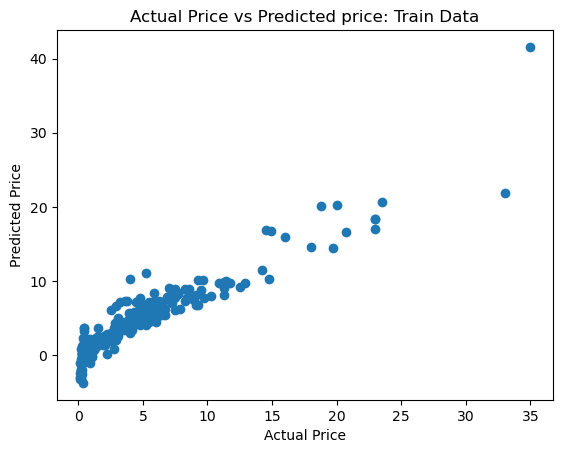

In [41]:
plt.scatter(Y_train,Train_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted price: Train Data")
plt.show()

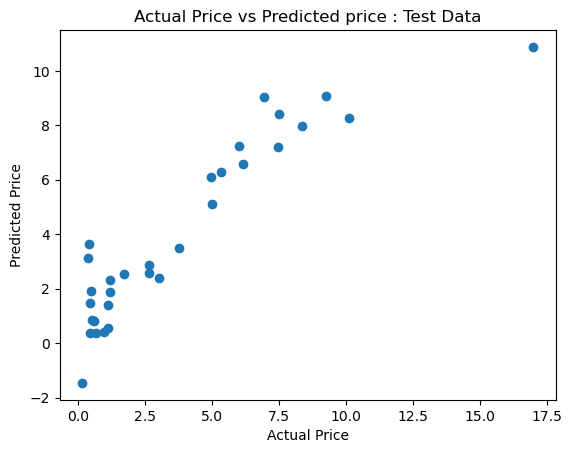

In [42]:
##Test DAta test

plt.scatter(Y_test,Test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted price : Test Data")
plt.show()

In [47]:
## A predicting mopdel

input_data = [2007,9.54,70000,0,1,0,0]

# inputr data as np array
input_data_np = np.asarray(input_data)

# input data reshaped
input_data_reshaped = input_data_np.reshape(1,-1)

# model pediction 

Prediction = model.predict(input_data_reshaped)

print(f"The car specification which u have given is predictded as {Prediction*10000} BY MODEL")

The car specification which u have given is predictded as [14313.50282752] BY MODEL


d:\HP\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
